In [1]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('..')

from tools.geometry import generate_detector
from tools.utils import load_single_event, save_single_event, generate_random_params
from tools.losses import compute_loss_with_time
from tools.simulation import setup_event_simulator

import jax
import jax.numpy as jnp
import time

from jax import jit
from pathlib import Path

from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

import numpy as jnp
from functools import partial
import pickle
from tqdm import tqdm
from jax import grad, jit, vmap, value_and_grad
from tools.losses import compute_simplified_loss

In [2]:
default_json_filename = '../config/IWCD_geom_config.json'

detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
detector_radius = detector.S_radius
NUM_DETECTORS = len(detector_points)
Nphot = 1_000_000

temperatures = [0.0, 0.2]

event_simulators = {temperature: setup_event_simulator(default_json_filename, Nphot, temperature) for temperature in temperatures}

# temperature is the relaxation used for overlap probability.
temperature = None

simulate_true_data = setup_event_simulator(default_json_filename, Nphot, temperature=temperature, is_data=False, is_calibration=False)

In [3]:
temperature_sim = 0.2
simulate_event = event_simulators[temperature_sim]

In [4]:
from tools.utils import generate_random_params

# Generate and save a single event
key = jax.random.PRNGKey(719007)

trk_params = generate_random_params(key)
detector_params = (
    jnp.array(4.),           # scatter_length
    jnp.array(0.2),         # reflection_rate
    jnp.array(6.),         # absorption_length
    jnp.array(0.001)         # gumbel_softmax_temp
)


single_event_data = jax.lax.stop_gradient(simulate_event(trk_params, detector_params, key))
save_single_event(single_event_data, trk_params, detector_params, filename='../events/test_event_data.h5', calibration_mode=False)

'../events/test_event_data.h5'

In [1]:
# %%timeit
#
# # get a random key from time
# key = jax.random.PRNGKey(int(time.time()))
#
# trk_params = generate_random_params(key)
#
# single_event_data = jax.lax.stop_gradient(simulate_event(trk_params, detector_params, key))

In [5]:
from tools.geometry import generate_detector
import jax.numpy as jnp
default_json_filename='../config/IWCD_geom_config.json'
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS = len(detector_points)
print(NUM_DETECTORS)

9720


Particle Parameters:
  Energy: 628.12 MeV
  Position: [-0.81, 0.05, 0.23] m
  Direction angles: theta=2.12 rad, phi=4.21 rad
  Direction vector: [-0.41, -0.75, -0.52]


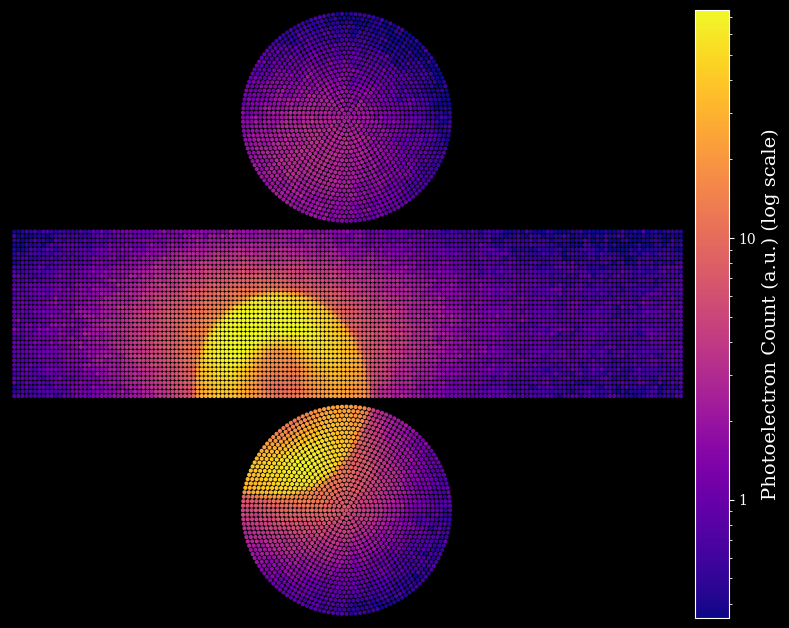

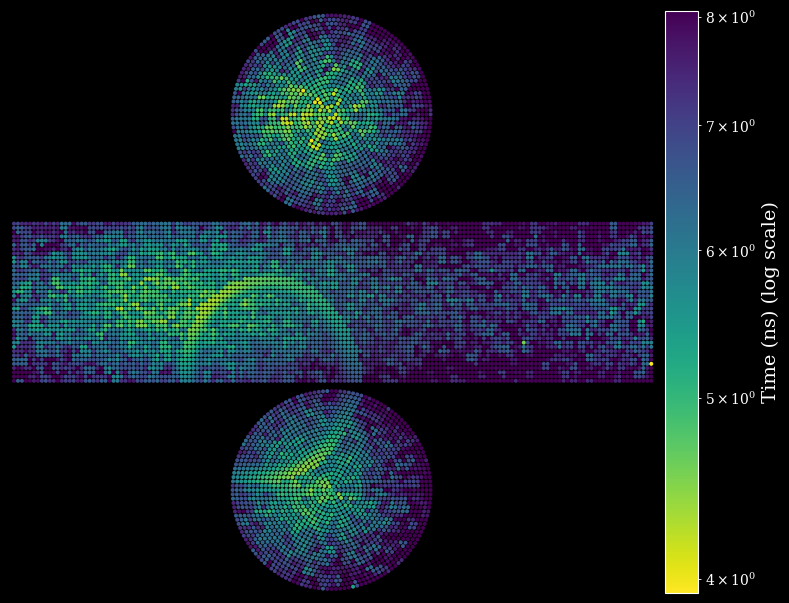

In [6]:
from tools.visualization import create_detector_display
from tools.utils import load_single_event, save_single_event, full_to_sparse, sparse_to_full, print_particle_params#, print_detector_params

event_location = '../events/test_event_data.h5'

figures_dir = Path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)

loaded_trk_params, loaded_detector_params, loaded_indices, loaded_charges, loaded_times= load_single_event(event_location, NUM_DETECTORS, calibration_mode=False)
print_particle_params(loaded_trk_params)#, print_detector_params(loaded_detector_params)

detector_display = create_detector_display(default_json_filename)
detector_display(loaded_indices, loaded_charges, loaded_times, file_name='figures/event_display_charge.png', plot_time=False, log_scale=True)
detector_display(loaded_indices, loaded_charges, loaded_times, file_name='figures/event_display_time.png', plot_time=True, log_scale=True, perc_min=0.0, perc_max=90.0)

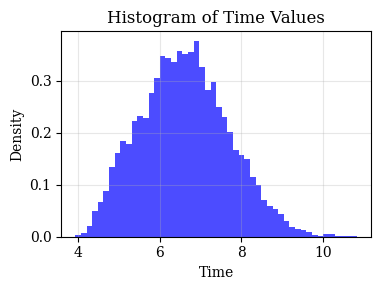

In [7]:
# Plot histogram of time values
plt.figure(figsize=(4, 3))
plt.hist(loaded_times, bins=50, alpha=0.7, color='blue', density=True)
plt.xlabel('Time')
plt.ylabel('Density')
plt.title('Histogram of Time Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()


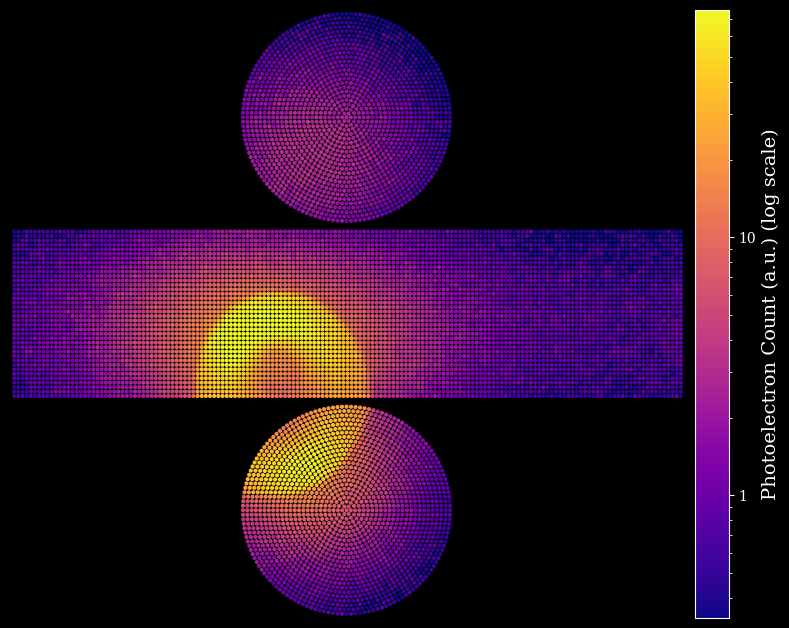

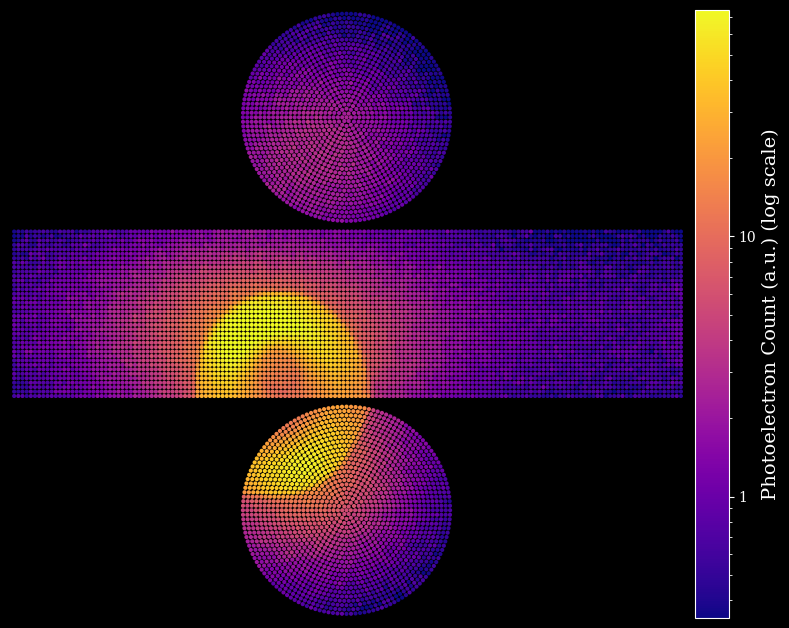

MAX ABS VALUE:  14.511258
MAX ABS VALUE:  10.400811
MAX ABS VALUE:  4.0806046


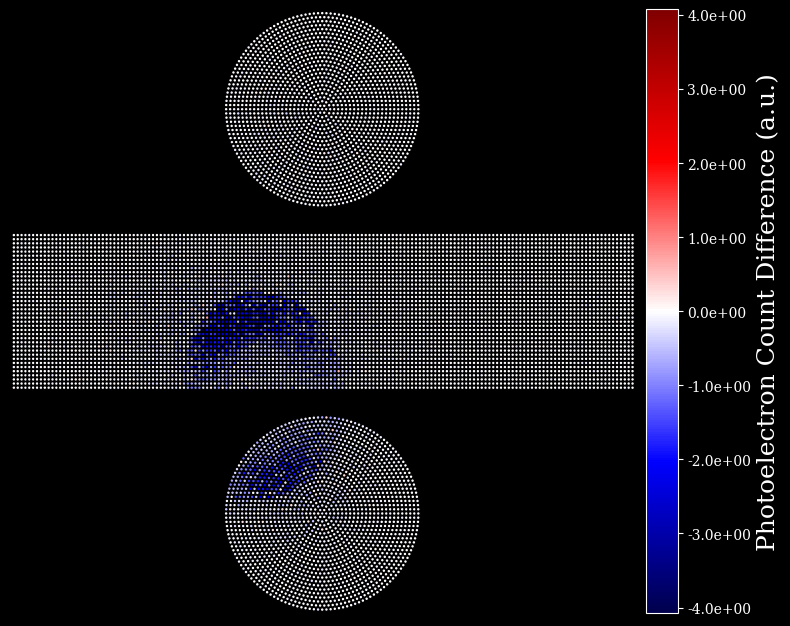

MAX ABS VALUE:  14.511258
MAX ABS VALUE:  10.400811
MAX ABS VALUE:  7.1391506


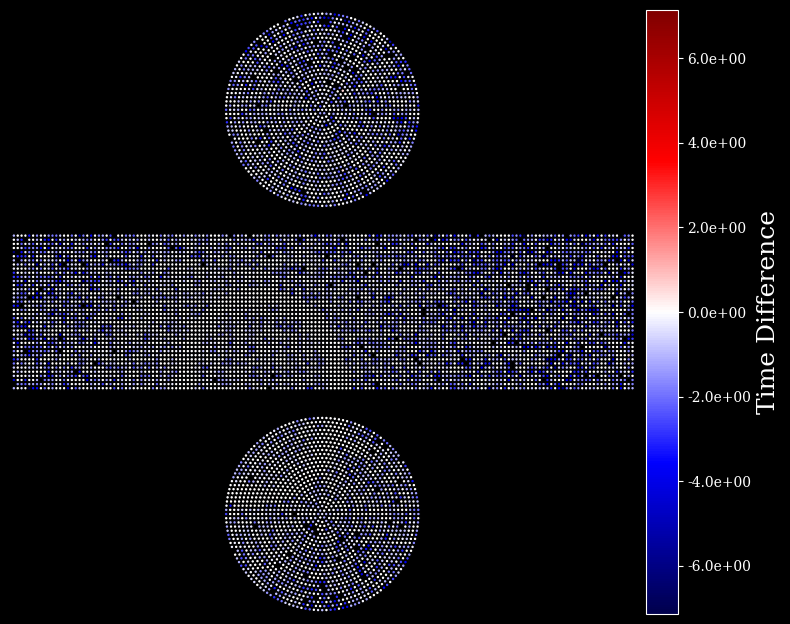

Average charge difference: 0.18085430562496185
Normalized average charge difference: 0.0017770759295672178
Average time difference: 6.251864874684543e-07
Normalized average time difference: 4.308285994625294e-08


In [8]:
# Evaluate Relaxation Difference
from tools.visualization import create_detector_comparison_display

detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
detector_radius = detector.S_radius
NUM_DETECTORS = len(detector_points)
Nphot = 500_000

# Generate events with same parameters but different temperatures
key = jax.random.PRNGKey(7109090)

# Use your existing parameter configuration
true_trk_params = generate_random_params(key)

# Generate events
event_data =  jax.lax.stop_gradient(simulate_true_data(trk_params, detector_params, key))

event_sim = simulate_event(trk_params, detector_params, key)

# Create regular displays for both temperatures
detector_display = create_detector_display(default_json_filename, sparse=False)

# Display individual events
detector_display(*event_data, file_name=None, plot_time=False, log_scale=True)
detector_display(*event_sim, file_name=None, plot_time=False, log_scale=True)

# Create comparison display
detector_comparison = create_detector_comparison_display(default_json_filename, sparse=False)

# Display differences with time alignment
detector_comparison(event_data, event_sim, file_name=None, plot_time=False)
detector_comparison(event_data, event_sim, file_name=None, plot_time=True, align_time=True)

indices1, charges1, times1 = full_to_sparse(*event_data)
indices2, charges2, times2 = full_to_sparse(*event_sim)

# If you want to calculate averages of differences
charges_full1 = sparse_to_full(indices1, charges1, NUM_DETECTORS)
charges_full2 = sparse_to_full(indices2, charges2, NUM_DETECTORS)
charge_diff = charges_full2 - charges_full1
charge_diff_avg = jnp.mean(jnp.abs(charge_diff[charge_diff != 0]))

# Calculate time differences with alignment
times_full1 = sparse_to_full(indices1, times1, NUM_DETECTORS)
times_full2 = sparse_to_full(indices2, times2, NUM_DETECTORS)
active_times1 = times_full1 > 0
active_times2 = times_full2 > 0
times1_mean = jnp.mean(times_full1[active_times1])
times2_mean = jnp.mean(times_full2[active_times2])
times_aligned1 = jnp.where(active_times1, times_full1 - times1_mean, 0)
times_aligned2 = jnp.where(active_times2, times_full2 - times2_mean, 0)
time_diff = times_aligned2 - times_aligned1
time_diff_avg = jnp.mean(time_diff[time_diff != 0])

print(f'Average charge difference: {charge_diff_avg}')
print(f"Normalized average charge difference: {charge_diff_avg/jnp.max(charges_full1)}")
print(f'Average time difference: {time_diff_avg}')
print(f'Normalized average time difference: {time_diff_avg/jnp.max(times_full1)}')

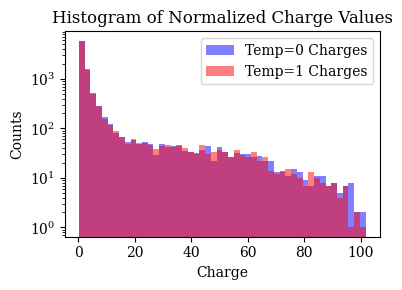

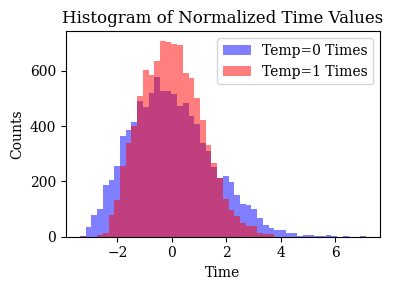

In [9]:
# plot histogram of charges
plt.figure(figsize=(4, 3))

range_values = (jnp.min(jnp.concatenate([charges1, charges2])), jnp.max(jnp.concatenate([charges1, charges2])))
plt.hist(charges1, bins=50, alpha=0.5, label='Temp=0 Charges', color='b', range=range_values)
plt.hist(charges2, bins=50, alpha=0.5, label='Temp=1 Charges', color='r', range=range_values)
plt.xlabel('Charge')
plt.ylabel('Counts')
# set y log scale
plt.yscale('log')
plt.title('Histogram of Normalized Charge Values')
plt.legend()
plt.tight_layout()
plt.show()

# plot histogram of times
plt.figure(figsize=(4, 3))

range_values = (jnp.min(jnp.concatenate([times_aligned1, times_aligned2])), jnp.max(jnp.concatenate([times_aligned1, times_aligned2])))
plt.hist(times_aligned1, bins=50, alpha=0.5, label='Temp=0 Times', color='b', range=range_values, density=False)
plt.hist(times_aligned2, bins=50, alpha=0.5, label='Temp=1 Times', color='r', range=range_values, density=False)
plt.xlabel('Time')
plt.ylabel('Counts')
plt.title('Histogram of Normalized Time Values')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Define parameter changes as percentages of true values
param_changes = (
    jnp.array(200.0),             # Energy in MeV
    jnp.array([1.5, 0.0, 0.0]),   # position
    jnp.array([1,0]),  # direction
)

key_id = 149790000
key = jax.random.PRNGKey(key_id)

true_params = generate_random_params(key)
true_data =  jax.lax.stop_gradient(simulate_true_data(true_params, detector_params, key))

print_particle_params(true_params)

Particle Parameters:
  Energy: 652.69 MeV
  Position: [-0.82, -0.14, -0.42] m
  Direction angles: theta=1.01 rad, phi=3.99 rad
  Direction vector: [-0.56, -0.64, 0.53]




Running analyses for Temperature = 0.0

PARTICLE GRADIENT ANALYSIS - ALL LAMBDA CASES

Running Lambda Intensity Analysis...


Intensity T=0.0: 100%|██████████| 4/4 [03:02<00:00, 45.55s/it]
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


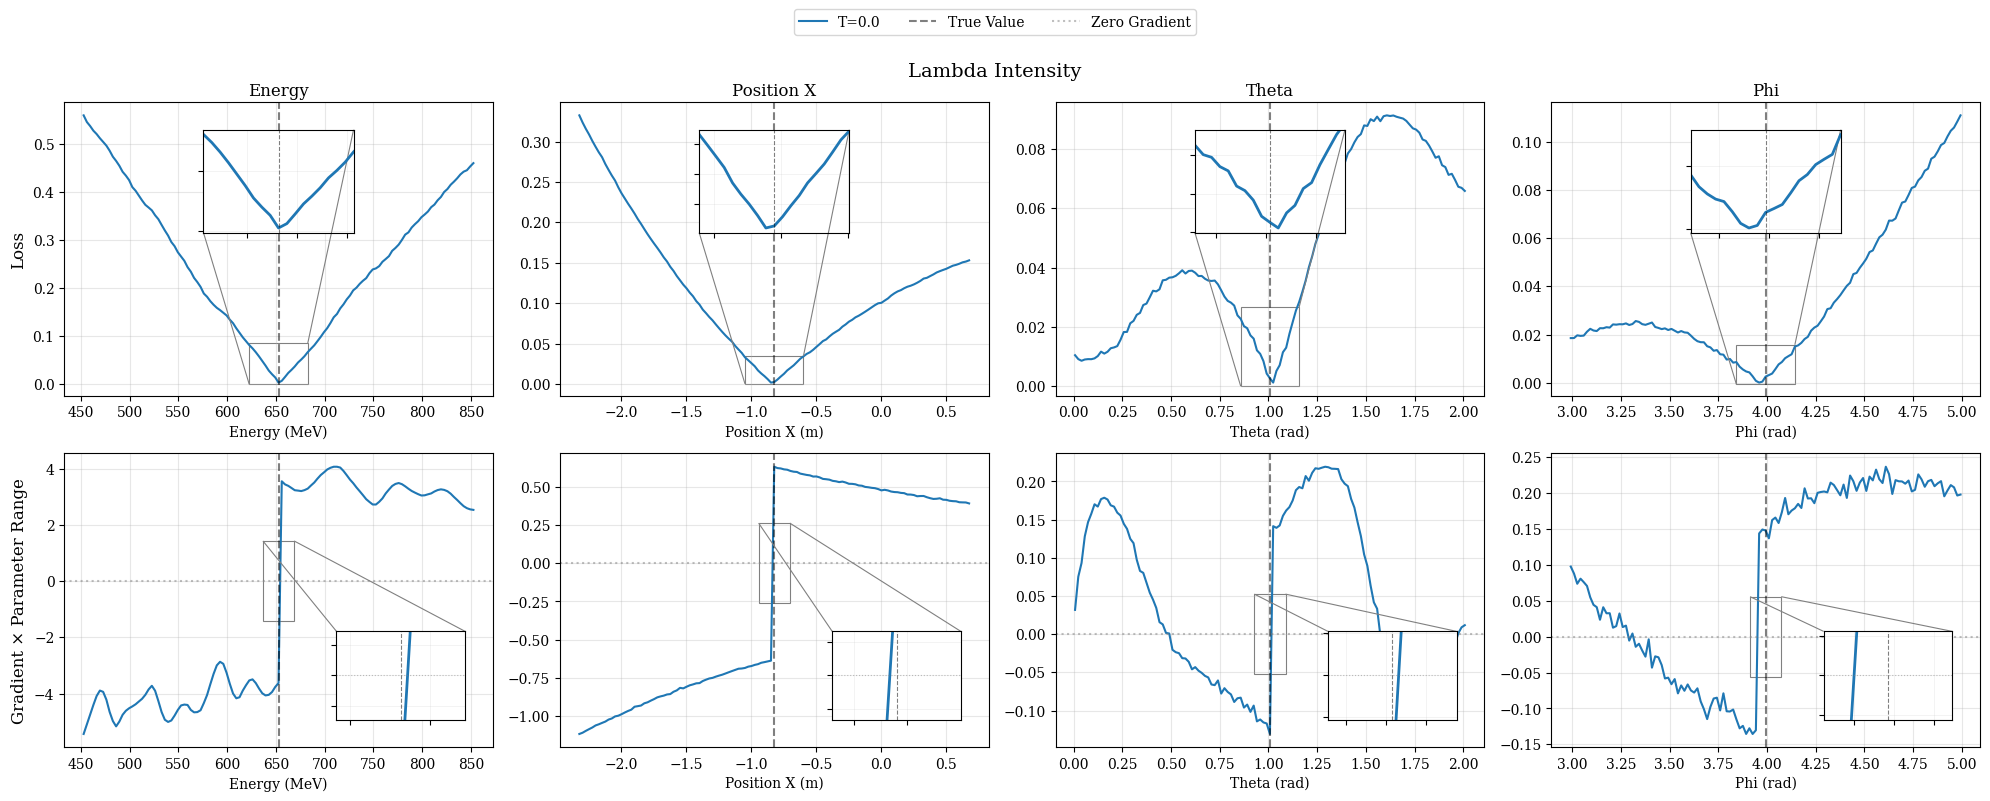


Running Lambda Charge Analysis...


Charge T=0.0 τ=0.5: 100%|██████████| 4/4 [02:45<00:00, 41.29s/it]
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


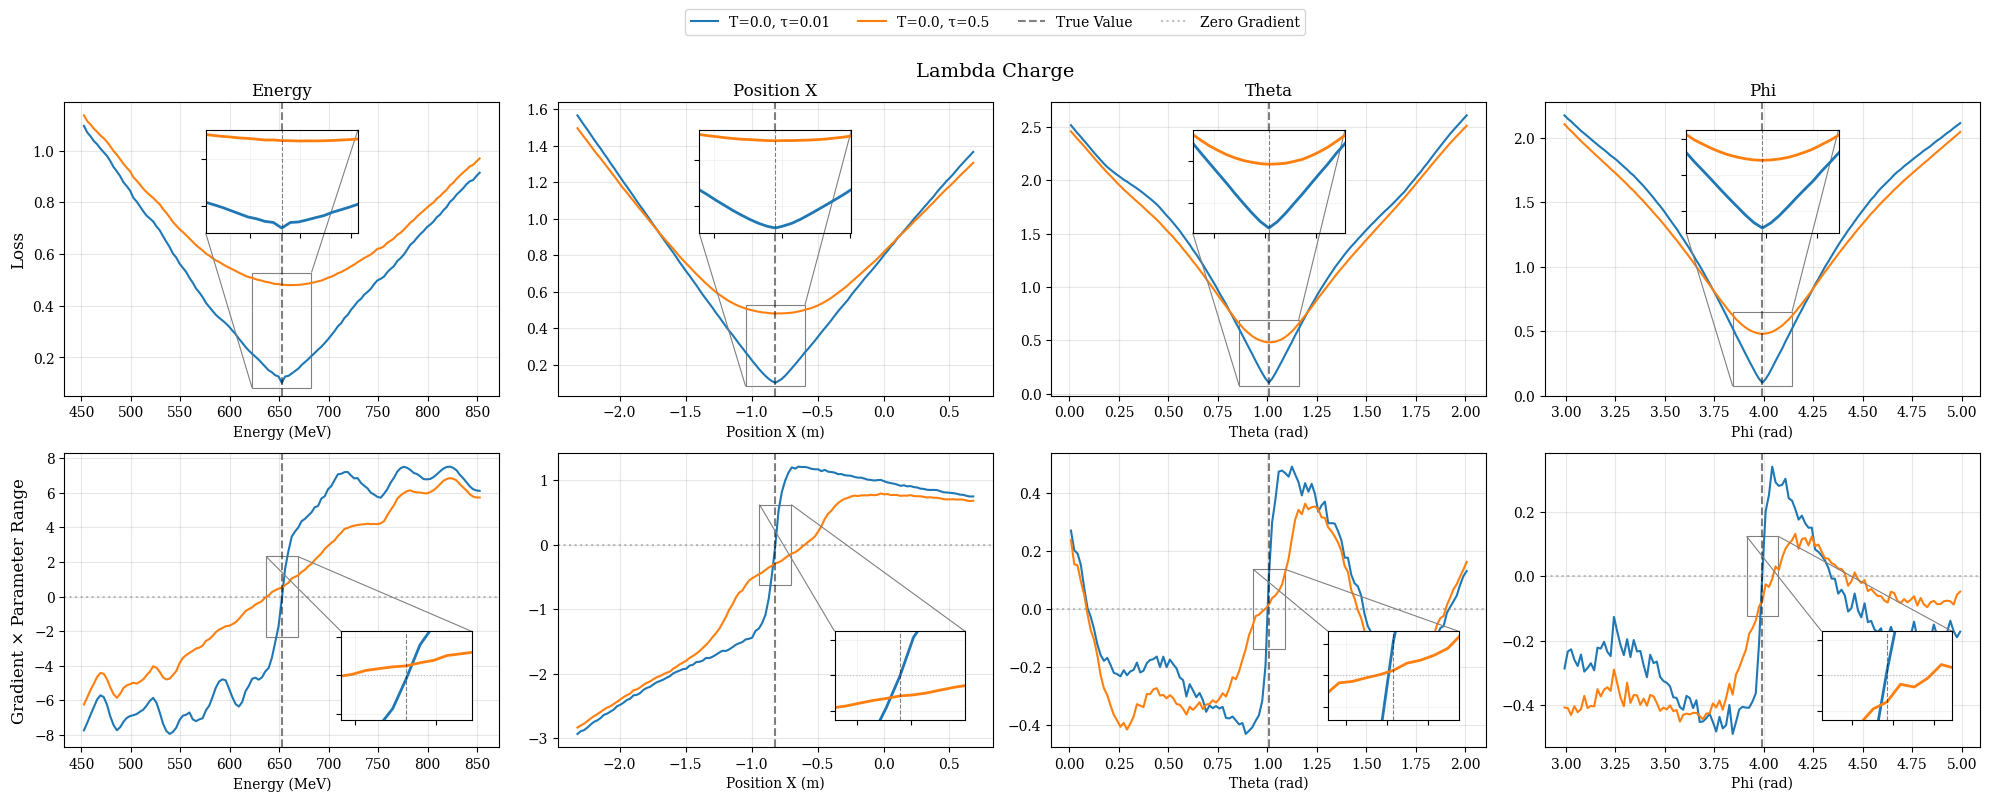


Running Lambda Time Analysis...


Time T=0.0 cutoff=20%: 100%|██████████| 4/4 [02:34<00:00, 38.69s/it]
/tmp/ipykernel_775867/2821669578.py:619: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axins_grad.set_ylim(y1_clipped, y2_clipped)
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


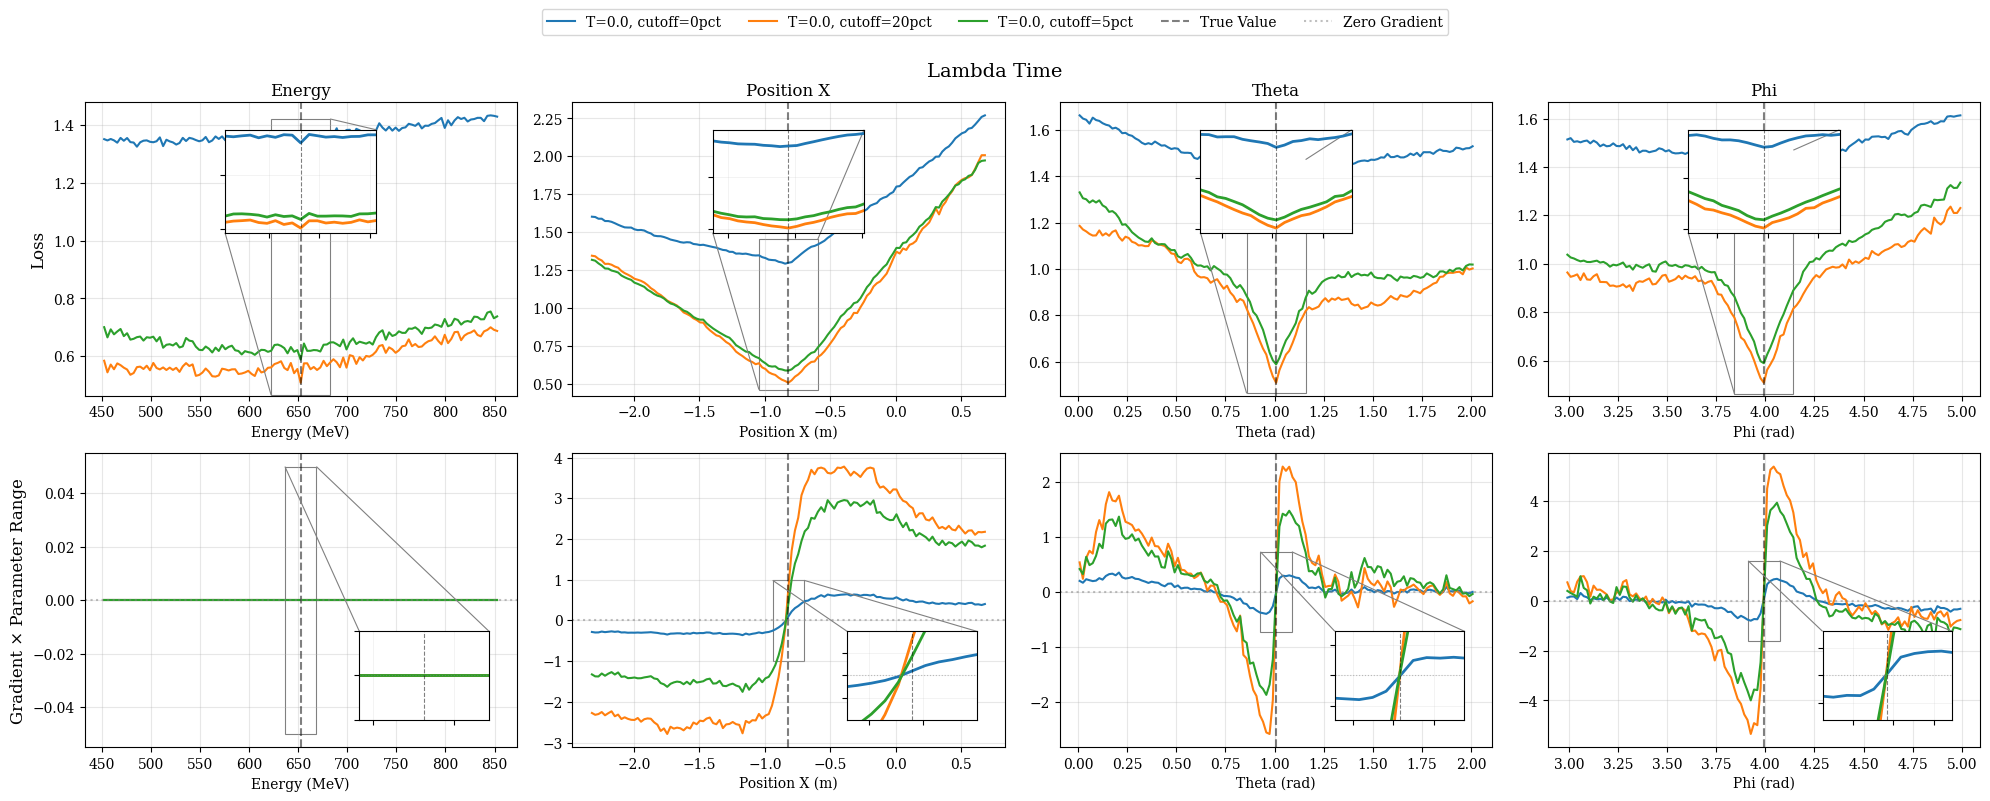


ALL ANALYSES COMPLETE!


Running analyses for Temperature = 0.2

PARTICLE GRADIENT ANALYSIS - ALL LAMBDA CASES

Running Lambda Intensity Analysis...


Intensity T=0.2: 100%|██████████| 4/4 [02:44<00:00, 41.17s/it]
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


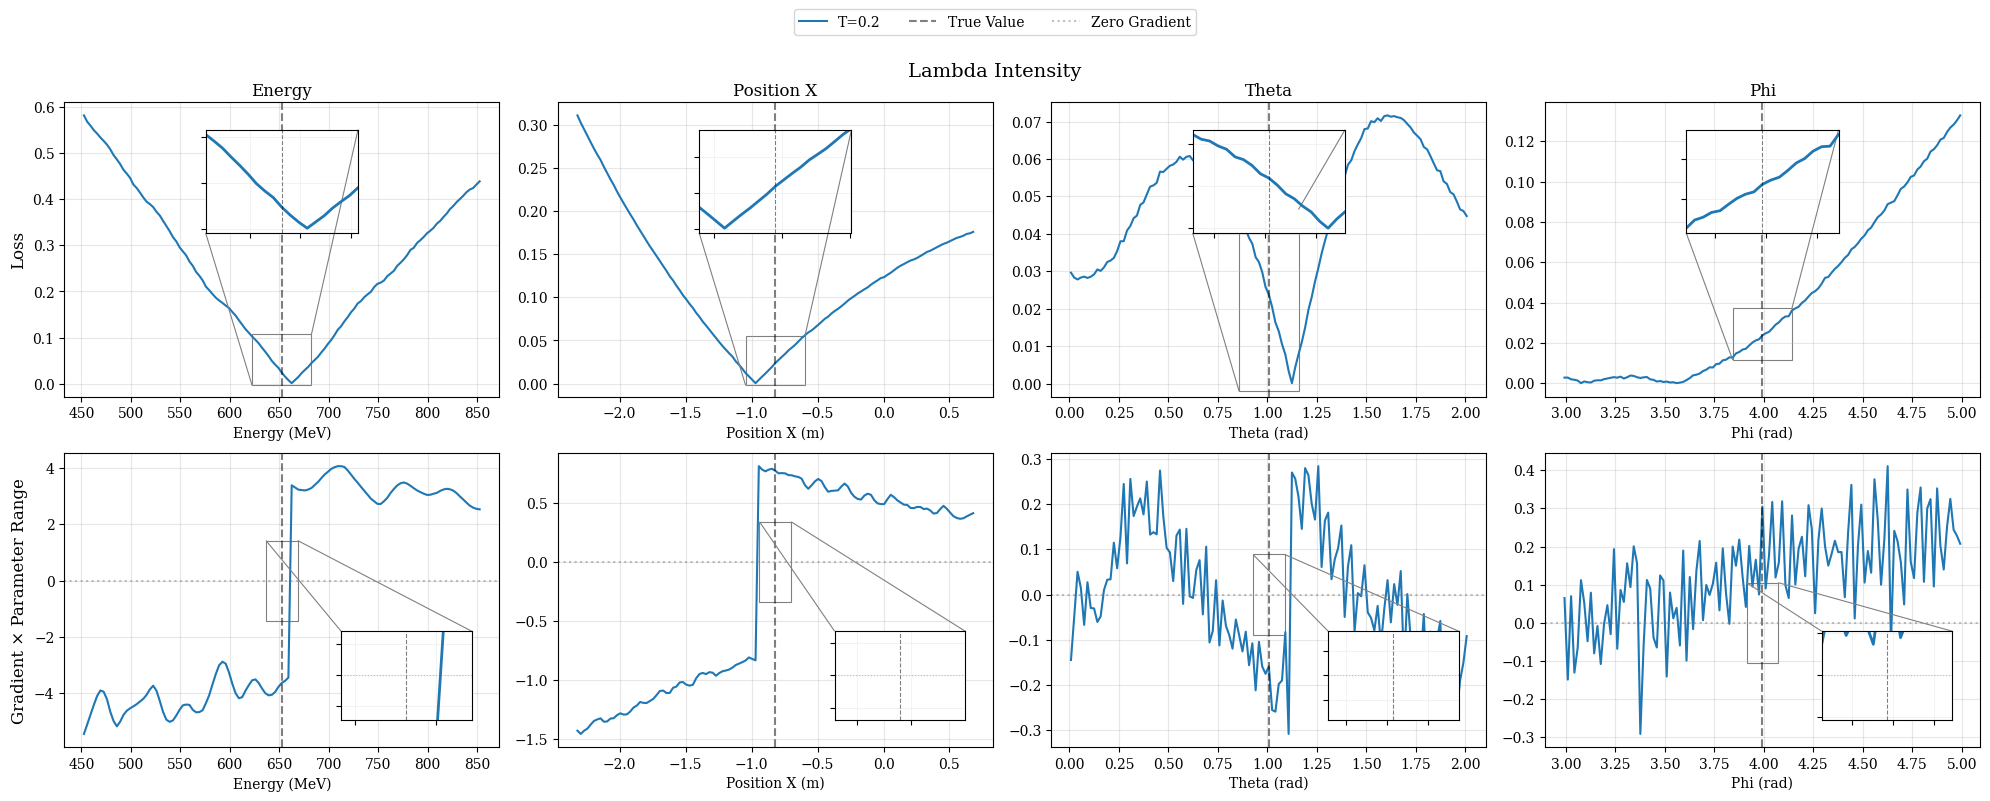


Running Lambda Charge Analysis...


Charge T=0.2 τ=0.5: 100%|██████████| 4/4 [02:48<00:00, 42.05s/it]
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


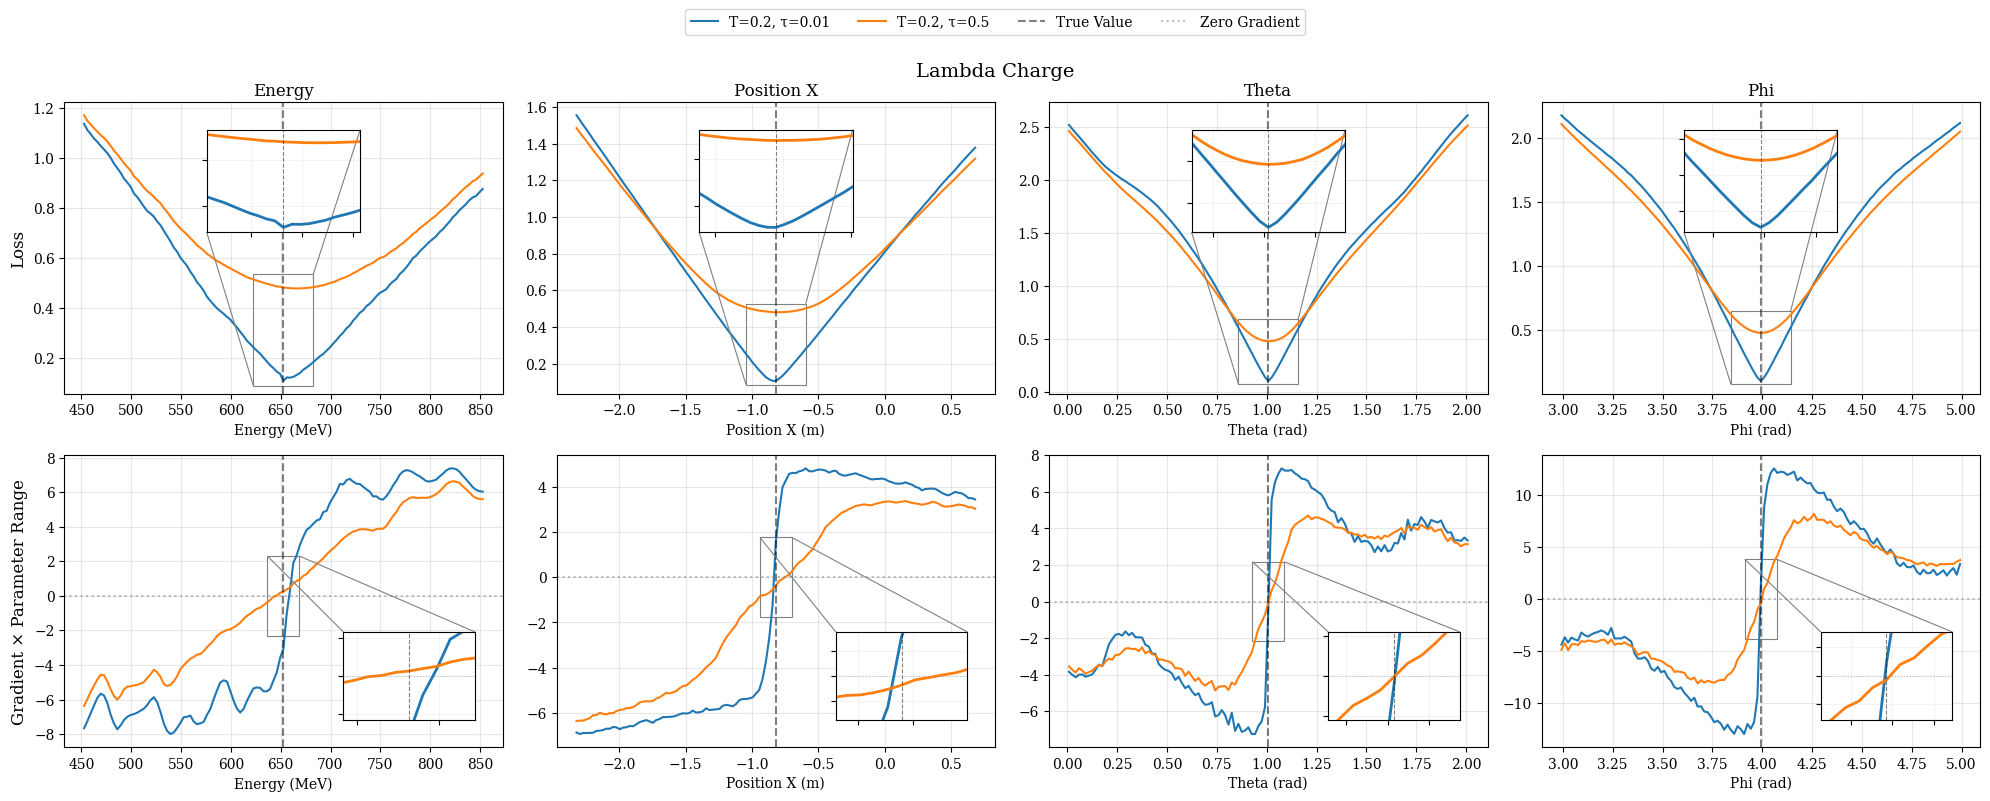


Running Lambda Time Analysis...


Time T=0.2 cutoff=20%: 100%|██████████| 4/4 [02:43<00:00, 40.87s/it]
/tmp/ipykernel_775867/2821669578.py:619: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axins_grad.set_ylim(y1_clipped, y2_clipped)
/tmp/ipykernel_775867/2821669578.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


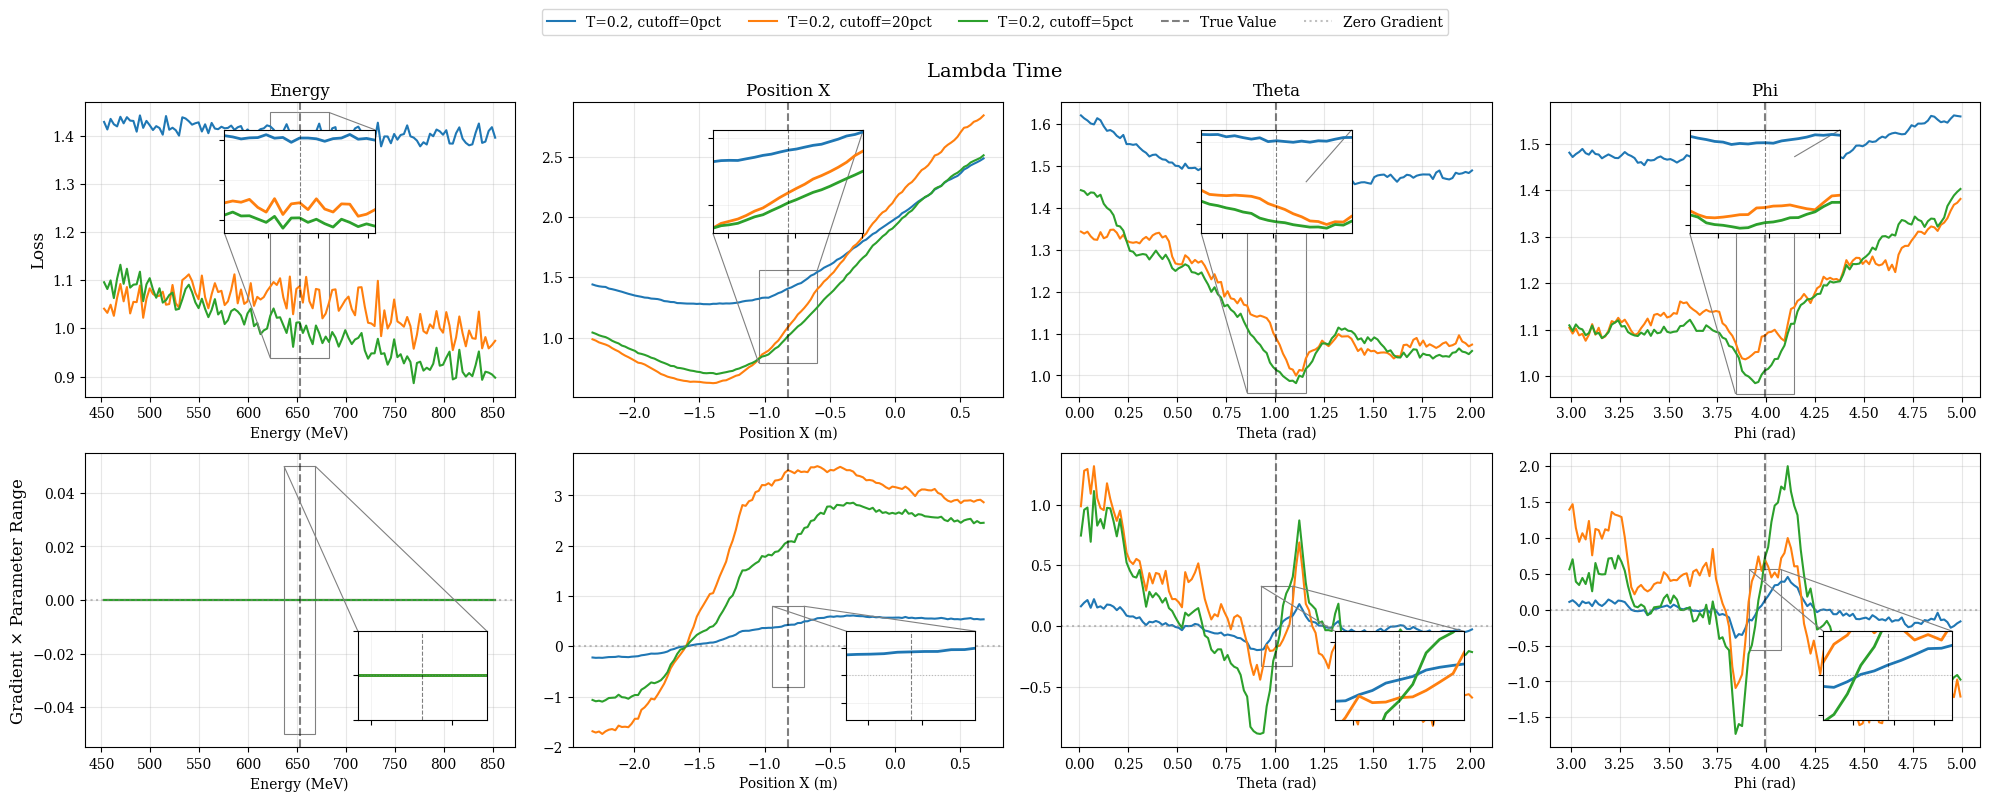


ALL ANALYSES COMPLETE!


In [11]:
# Part 1: Data Generation for Track Parameters (No Detector Params)
from tools.losses import compute_softmin_loss
import jax.numpy as jnp
from jax import jit, value_and_grad
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# Define parameter min/max ranges based on detector geometry
# detector.r gives cylinder radius, detector.H gives height
param_min_max = (
    (0.0001, 1000.0),                    # Energy in MeV (min, max)
    (-detector.r, detector.r),           # Position X in meters (min, max)
    (-detector.r, detector.r),           # Position Y in meters (min, max)
    (-detector.H/2, detector.H/2),       # Position Z in meters (min, max)
    (0, 3.14159),                         # Theta (polar angle) in radians: 0 to π
    (0, 6.28318)                          # Phi (azimuthal angle) in radians: 0 to 2π
)

# Calculate parameter ranges (max - min) for gradient scaling
param_range_scales = jnp.array([
    param_min_max[0][1] - param_min_max[0][0],  # Energy range
    param_min_max[1][1] - param_min_max[1][0],  # Position X range
    param_min_max[2][1] - param_min_max[2][0],  # Position Y range (not used in analysis)
    param_min_max[3][1] - param_min_max[3][0],  # Position Z range (not used in analysis)
    param_min_max[4][1] - param_min_max[4][0],  # Theta range
    param_min_max[5][1] - param_min_max[5][0]   # Phi range
])

# Define parameter changes for particle parameters only
param_changes = (
    jnp.array(200.0),             # Energy in MeV
    jnp.array([1.5, 0.0, 0.0]),   # position
    jnp.array([1.0, 0]),           # theta
    jnp.array([1.0, 0]),           # phi
)

def generate_param_ranges(particle_params, param_changes, num_points=121):
  param_ranges = []

  # Extract the 4 parameters we want from the 3-element particle_params
  # particle_params is (energy, position, direction)
  params_to_vary = [
      particle_params[0],           # Energy
      particle_params[1],           # Position (we'll use x component)
      particle_params[2],           # Direction (we'll use theta)
      particle_params[2]            # Direction (we'll use phi)
  ]

  # Process the 4 parameters
  for i in range(4):
      param = params_to_vary[i]
      change = param_changes[i]

      if i == 0:  # energy
          start = max(param - change, 0.0001)
          end = param + change
      elif i == 1:  # position x
          start = param[0] - change[0]
          end = param[0] + change[0]
      elif i == 2:  # theta (first component of direction)
          start = param[0] - change[0]
          end = param[0] + change[0]
      elif i == 3:  # phi (second component of direction)
          start = param[1] - change[0]
          end = param[1] + change[0]
      param_ranges.append(jnp.linspace(start, end, num_points))

  return param_ranges

def generate_plot_data_intensity(param_index, param_values, simulator, particle_params,
                                 detector_params, key, true_data, detector_points, tau_val):
    losses = []
    gradients = []

    loss_and_grad_fn = create_loss_and_grad_fn_intensity(
        simulator, key, true_data, detector_points)

    # Get the appropriate parameter range scale
    # Map param_index to the correct scale: 0->Energy, 1->X, 2->Theta, 3->Phi
    param_scale_indices = [0, 1, 4, 5]  # Energy, X, Theta, Phi
    param_scale = param_range_scales[param_scale_indices[param_index]]

    for new_value in param_values:
        # Modify particle parameter
        new_p_params = list(particle_params)

        if param_index == 0:  # Energy
            new_p_params[0] = new_value
        elif param_index == 1:  # Position X
            new_p_params[1] = new_p_params[1].at[0].set(new_value)
        elif param_index == 2:  # Theta (first component of direction)
            new_p_params[2] = new_p_params[2].at[0].set(new_value)
        elif param_index == 3:  # Phi (second component of direction)
            new_p_params[2] = new_p_params[2].at[1].set(new_value)

        new_p_params = tuple(new_p_params)

        # Calculate loss and gradient with fixed detector params
        loss, grad = loss_and_grad_fn(new_p_params, detector_params, tau_val)

        # Extract gradient for the specific parameter
        if param_index == 0:  # Energy
            gradient = grad[0]
        elif param_index == 1:  # Position X
            gradient = grad[1][0]
        elif param_index == 2:  # Theta
            gradient = grad[2][0]
        elif param_index == 3:  # Phi
            gradient = grad[2][1]

        # Multiply gradient by parameter range
        gradient = gradient * param_scale

        losses.append(loss)
        gradients.append(gradient)

    return jnp.array(losses), jnp.array(gradients)

def generate_plot_data_charge(param_index, param_values, simulator, particle_params,
                             detector_params, key, true_data, detector_points, tau_val):
    losses = []
    gradients = []

    loss_and_grad_fn = create_loss_and_grad_fn_charge(
        simulator, key, true_data, detector_points)

    # Get the appropriate parameter range scale
    # Map param_index to the correct scale: 0->Energy, 1->X, 2->Theta, 3->Phi
    param_scale_indices = [0, 1, 4, 5]  # Energy, X, Theta, Phi
    param_scale = param_range_scales[param_scale_indices[param_index]]

    for new_value in param_values:
        # Modify particle parameter
        new_p_params = list(particle_params)

        if param_index == 0:  # Energy
            new_p_params[0] = new_value
        elif param_index == 1:  # Position X
            new_p_params[1] = new_p_params[1].at[0].set(new_value)
        elif param_index == 2:  # Theta (first component of direction)
            new_p_params[2] = new_p_params[2].at[0].set(new_value)
        elif param_index == 3:  # Phi (second component of direction)
            new_p_params[2] = new_p_params[2].at[1].set(new_value)

        new_p_params = tuple(new_p_params)

        # Calculate loss and gradient with fixed detector params
        loss, grad = loss_and_grad_fn(new_p_params, detector_params, tau_val)

        # Extract gradient for the specific parameter
        if param_index == 0:  # Energy
            gradient = grad[0]
        elif param_index == 1:  # Position X
            gradient = grad[1][0]
        elif param_index == 2:  # Theta
            gradient = grad[2][0]
        elif param_index == 3:  # Phi
            gradient = grad[2][1]

        # Multiply gradient by parameter range
        gradient = gradient * param_scale

        losses.append(loss)
        gradients.append(gradient)

    return jnp.array(losses), jnp.array(gradients)

def generate_plot_data_time(param_index, param_values, simulator, particle_params,
                           detector_params, key, true_data, detector_points,
                           cutoff_threshold, tau_val=0.01):
    losses = []
    gradients = []

    loss_and_grad_fn = create_loss_and_grad_fn_time(
        simulator, key, true_data, detector_points)

    # Get the appropriate parameter range scale
    # Map param_index to the correct scale: 0->Energy, 1->X, 2->Theta, 3->Phi
    param_scale_indices = [0, 1, 4, 5]  # Energy, X, Theta, Phi
    param_scale = param_range_scales[param_scale_indices[param_index]]

    for new_value in param_values:
        # Modify particle parameter
        new_p_params = list(particle_params)

        if param_index == 0:  # Energy
            new_p_params[0] = new_value
        elif param_index == 1:  # Position X
            new_p_params[1] = new_p_params[1].at[0].set(new_value)
        elif param_index == 2:  # Theta (first component of direction)
            new_p_params[2] = new_p_params[2].at[0].set(new_value)
        elif param_index == 3:  # Phi (second component of direction)
            new_p_params[2] = new_p_params[2].at[1].set(new_value)

        new_p_params = tuple(new_p_params)

        # Calculate loss and gradient with fixed detector params
        loss, grad = loss_and_grad_fn(new_p_params, detector_params, tau_val, cutoff_threshold)

        # Extract gradient for the specific parameter
        if param_index == 0:  # Energy
            gradient = grad[0]
        elif param_index == 1:  # Position X
            gradient = grad[1][0]
        elif param_index == 2:  # Theta
            gradient = grad[2][0]
        elif param_index == 3:  # Phi
            gradient = grad[2][1]

        # Multiply gradient by parameter range
        gradient = gradient * param_scale

        losses.append(loss)
        gradients.append(gradient)

    return jnp.array(losses), jnp.array(gradients)

def create_loss_and_grad_fn_intensity(simulator, key, true_data, detector_points):
    @jit
    def loss_and_grad_fn_particle(p_params, d_params, tau_val):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return compute_softmin_loss(
                detector_points, *true_data, *simulated_data,
                tau=tau_val,
                threshold_mean=1e-8,
                threshold_loss=0.00001,
                lambda_time=0.0,
                lambda_charge=0.0,
                lambda_intensity=1.0
            )
        return value_and_grad(loss_fn)(p_params)

    return loss_and_grad_fn_particle

def create_loss_and_grad_fn_charge(simulator, key, true_data, detector_points):
    @jit
    def loss_and_grad_fn_particle(p_params, d_params, tau_val):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return compute_softmin_loss(
                detector_points, *true_data, *simulated_data,
                tau=tau_val,
                threshold_mean=1e-8,
                threshold_loss=0.00001,
                lambda_time=0.0,
                lambda_charge=1.0,
                lambda_intensity=0.0
            )
        return value_and_grad(loss_fn)(p_params)

    return loss_and_grad_fn_particle

def create_loss_and_grad_fn_time(simulator, key, true_data, detector_points):
    @jit
    def loss_and_grad_fn_particle(p_params, d_params, tau_val, cutoff_threshold):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return compute_softmin_loss(
                detector_points, *true_data, *simulated_data,
                tau=tau_val,
                threshold_mean=1e-8,
                threshold_loss=cutoff_threshold,
                lambda_time=1.0,
                lambda_charge=0.0,
                lambda_intensity=0.0
            )
        return value_and_grad(loss_fn)(p_params)

    return loss_and_grad_fn_particle

def generate_analysis_data_intensity(particle_params, param_changes, temperatures, tau_values,
                                     event_simulators, detector_params_dict, key,
                                     true_data_dict, detector_points, num_points=121):
    """Generate analysis data for lambda_intensity case."""
    # Generate parameter ranges
    param_ranges = generate_param_ranges(particle_params, param_changes, num_points)
    param_names = ['Energy', 'Position X', 'Theta', 'Phi']

    # Store all data in a dictionary
    analysis_data = {
        'param_ranges': param_ranges,
        'param_names': param_names,
        'particle_params': particle_params,
        'case': 'lambda_intensity',
        'results': {}
    }

    # For intensity, tau doesn't matter so use fixed value
    fixed_tau = 0.01

    # Generate data for each temperature only (tau doesn't affect intensity loss)
    for temp in temperatures:
        condition_key = f'temp_{temp}_tau_{fixed_tau}'
        simulator = event_simulators[temp]
        # Use the first tau value's detector params
        detector_params = detector_params_dict[f'tau_{fixed_tau}']
        true_data = true_data_dict[f'tau_{fixed_tau}']

        analysis_data['results'][condition_key] = {}

        desc = f"Intensity T={temp}"
        for param_idx, param_name in enumerate(tqdm(param_names, desc=desc)):
            param_values = param_ranges[param_idx]
            losses, gradients = generate_plot_data_intensity(
                param_idx, param_values, simulator,
                particle_params, detector_params, key, true_data, detector_points, fixed_tau
            )
            analysis_data['results'][condition_key][param_name] = {
                'losses': losses,
                'gradients': gradients
            }

    return analysis_data

def generate_analysis_data_charge(particle_params, param_changes, temperatures, tau_values,
                                 event_simulators, detector_params_dict, key,
                                 true_data_dict, detector_points, num_points=121):
    """Generate analysis data for lambda_charge case."""
    # Generate parameter ranges
    param_ranges = generate_param_ranges(particle_params, param_changes, num_points)
    param_names = ['Energy', 'Position X', 'Theta', 'Phi']

    # Store all data in a dictionary
    analysis_data = {
        'param_ranges': param_ranges,
        'param_names': param_names,
        'particle_params': particle_params,
        'case': 'lambda_charge',
        'results': {}
    }

    # Generate data for each temperature and tau combination
    for temp in temperatures:
        for tau in tau_values:
            condition_key = f'temp_{temp}_tau_{tau}'
            simulator = event_simulators[temp]
            detector_params = detector_params_dict[f'tau_{tau}']
            true_data = true_data_dict[f'tau_{tau}']

            analysis_data['results'][condition_key] = {}

            for param_idx, param_name in enumerate(tqdm(param_names,
                                                        desc=f"Charge T={temp} τ={tau}")):
                param_values = param_ranges[param_idx]
                losses, gradients = generate_plot_data_charge(
                    param_idx, param_values, simulator,
                    particle_params, detector_params, key, true_data, detector_points, tau
                )
                analysis_data['results'][condition_key][param_name] = {
                    'losses': losses,
                    'gradients': gradients
                }

    return analysis_data

def generate_analysis_data_time(particle_params, param_changes, temperatures,
                               event_simulators, detector_params_dict, key,
                               true_data_dict, detector_points,
                               cutoff_thresholds, num_points=121):
    """Generate analysis data for lambda_time case."""
    # Generate parameter ranges
    param_ranges = generate_param_ranges(particle_params, param_changes, num_points)
    param_names = ['Energy', 'Position X', 'Theta', 'Phi']

    # Store all data in a dictionary
    analysis_data = {
        'param_ranges': param_ranges,
        'param_names': param_names,
        'particle_params': particle_params,
        'case': 'lambda_time',
        'results': {}
    }

    # Use fixed tau value for time analysis
    tau_for_time = 0.1

    # Generate data for each temperature and cutoff threshold combination
    for temp in temperatures:
        for cutoff_pct in cutoff_thresholds:
            condition_key = f'temp_{temp}_cutoff_{int(cutoff_pct*100)}pct'
            simulator = event_simulators[temp]
            # Use the first tau value's detector params for time analysis
            detector_params = detector_params_dict['tau_0.01']
            true_data = true_data_dict['tau_0.01']

            # Calculate actual cutoff threshold as percentage of max charge
            true_charge = true_data[0]  # First element is charge
            max_charge = jnp.max(true_charge)
            actual_cutoff_threshold = cutoff_pct * max_charge if cutoff_pct > 0 else 1e-8  # Use small value for 0%

            analysis_data['results'][condition_key] = {}

            desc = f"Time T={temp} cutoff={int(cutoff_pct*100)}%"
            for param_idx, param_name in enumerate(tqdm(param_names, desc=desc)):
                param_values = param_ranges[param_idx]
                losses, gradients = generate_plot_data_time(
                    param_idx, param_values, simulator,
                    particle_params, detector_params, key, true_data, detector_points,
                    actual_cutoff_threshold, tau_for_time
                )
                analysis_data['results'][condition_key][param_name] = {
                    'losses': losses,
                    'gradients': gradients
                }

    return analysis_data

def plot_analysis_results_with_zoom(analysis_data,
                                    show_loss_zoom=True,
                                    show_gradient_zoom=True,
                                    loss_inset_size="35%",
                                    gradient_inset_size="30%",
                                    loss_x_zoom_pct=0.15,
                                    gradient_x_zoom_pct=0.08,
                                    gradient_y_zoom_pct=0.3):
    """
    Plot the analysis results with 2 rows (loss/gradient) and 4 columns (parameters).
    Now with optional zoom-in functionality.

    Parameters:
    -----------
    analysis_data : dict
        The analysis data dictionary
    show_loss_zoom : bool
        Whether to show zoom-in boxes for loss plots
    show_gradient_zoom : bool
        Whether to show zoom-in boxes for gradient plots
    loss_inset_size : str
        Size of loss zoom inset as percentage (e.g., "35%")
    gradient_inset_size : str
        Size of gradient zoom inset as percentage (e.g., "30%")
    loss_x_zoom_pct : float
        Percentage of x-range for loss zoom window
    gradient_x_zoom_pct : float
        Percentage of x-range for gradient zoom window
    gradient_y_zoom_pct : float
        Percentage of y-range for gradient zoom window height
    """
    param_names = analysis_data['param_names']
    particle_params = analysis_data['particle_params']

    # Dynamically generate colors based on actual conditions
    condition_keys = sorted(analysis_data['results'].keys())
    color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    colors = {key: color_palette[i % len(color_palette)] for i, key in enumerate(condition_keys)}

    # Create figure with 2 rows and 4 columns
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))

    # Lists to store legend handles and labels
    all_lines = []
    all_labels = []

    # Plot for each parameter
    for param_idx, param_name in enumerate(param_names):
        ax_loss = axs[0, param_idx]
        ax_grad = axs[1, param_idx]

        param_values = analysis_data['param_ranges'][param_idx]

        # Determine true value based on parameter type
        if param_idx == 0:  # Energy
            true_value = particle_params[0]
        elif param_idx == 1:  # Position X
            true_value = particle_params[1][0]
        elif param_idx == 2:  # Theta (first component of direction)
            true_value = particle_params[2][0]
        elif param_idx == 3:  # Phi (second component of direction)
            true_value = particle_params[2][1]

        # Store data for zoom calculations
        all_losses = {}
        all_gradients = {}

        for condition_key in sorted(analysis_data['results'].keys()):
            results = analysis_data['results'][condition_key][param_name]
            losses = results['losses']
            gradients = results['gradients']

            all_losses[condition_key] = losses
            all_gradients[condition_key] = gradients

            # Create label based on condition
            if 'tau' in condition_key:
                parts = condition_key.split('_')
                temp = parts[1]
                tau = parts[3]
                # For intensity, don't show tau since it doesn't matter
                if 'lambda_intensity' in analysis_data['case']:
                    label = f'T={temp}'
                else:
                    label = f'T={temp}, τ={tau}'
            else:  # cutoff case
                parts = condition_key.split('_')
                temp = parts[1]
                cutoff_str = parts[3]
                label = f'T={temp}, cutoff={cutoff_str}'

            color = colors[condition_key]

            # Plot loss and gradient
            line_loss = ax_loss.plot(param_values, losses, color=color, lw=1.5)[0]
            line_grad = ax_grad.plot(param_values, gradients, color=color, lw=1.5)[0]

            # Only store legend items from the first parameter
            if param_idx == 0:
                all_lines.append(line_loss)
                all_labels.append(label)

        # Add reference lines
        true_line = ax_loss.axvline(x=true_value, color='black', linestyle='--', alpha=0.5)
        ax_grad.axvline(x=true_value, color='black', linestyle='--', alpha=0.5)
        zero_line = ax_grad.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

        # Only store reference lines from the first parameter
        if param_idx == 0:
            all_lines.extend([true_line, zero_line])
            all_labels.extend(['True Value', 'Zero Gradient'])

        # Configure axes
        ax_loss.set_title(f'{param_name}', pad=5, fontsize=12)

        # Set appropriate x-label based on parameter
        if param_name == 'Energy':
            ax_loss.set_xlabel(f'{param_name} (MeV)', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} (MeV)', fontsize=10)
        elif param_name == 'Position X':
            ax_loss.set_xlabel(f'{param_name} (m)', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} (m)', fontsize=10)
        else:  # Theta, Phi
            ax_loss.set_xlabel(f'{param_name} (rad)', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} (rad)', fontsize=10)

        # Only add y-label to leftmost plots
        if param_idx == 0:
            ax_loss.set_ylabel('Loss', fontsize=12)
            ax_grad.set_ylabel('Gradient × Parameter Range', fontsize=12)

        ax_loss.grid(True, alpha=0.3)
        ax_grad.grid(True, alpha=0.3)

        # Add zoom-in for loss plot
        if show_loss_zoom:
            # Define zoom region for loss
            x_range = param_values.max() - param_values.min()
            x_zoom_width = x_range * loss_x_zoom_pct
            x1 = true_value - x_zoom_width/2
            x2 = true_value + x_zoom_width/2

            # Y-range: fit all curves
            y_in_range = []
            for loss_vals in all_losses.values():
                mask = (param_values >= x1) & (param_values <= x2)
                y_in_range.extend(loss_vals[mask])
            y_margin = 0.05 * (max(y_in_range) - min(y_in_range))
            y1 = min(y_in_range) - y_margin
            y2 = max(y_in_range) + y_margin

            # Create loss inset
            axins_loss = inset_axes(ax_loss, width=loss_inset_size, height=loss_inset_size,
                                   loc='upper center', borderpad=2)

            # Plot in zoom window
            for condition_key, loss_vals in all_losses.items():
                axins_loss.plot(param_values, loss_vals, color=colors[condition_key], lw=2.0)

            axins_loss.axvline(x=true_value, color='black', linestyle='--', alpha=0.5, lw=0.8)
            axins_loss.set_xlim(x1, x2)

            # Ensure zoom y-range doesn't exceed main plot's y-range
            main_ylim_loss = ax_loss.get_ylim()
            y1_clipped = max(y1, main_ylim_loss[0])
            y2_clipped = min(y2, main_ylim_loss[1])
            axins_loss.set_ylim(y1_clipped, y2_clipped)
            axins_loss.set_xticklabels([])
            axins_loss.set_yticklabels([])
            axins_loss.grid(True, alpha=0.2, linewidth=0.5)
            mark_inset(ax_loss, axins_loss, loc1=3, loc2=1, fc="none", ec="0.5", lw=0.8)

        # Add zoom-in for gradient plot
        if show_gradient_zoom:
            # Define zoom region for gradient
            x_range = param_values.max() - param_values.min()
            x_zoom_width = x_range * gradient_x_zoom_pct
            x1 = true_value - x_zoom_width/2
            x2 = true_value + x_zoom_width/2

            # Y-range: fixed percentage of main plot range, centered on zero
            # First get the full y-range of the gradient data
            all_grad_flat = []
            for grad_vals in all_gradients.values():
                all_grad_flat.extend(grad_vals)

            main_grad_range = max(all_grad_flat) - min(all_grad_flat)
            y_zoom_height = main_grad_range * gradient_y_zoom_pct
            y1 = -y_zoom_height/2
            y2 = y_zoom_height/2

            # Create gradient inset
            axins_grad = inset_axes(ax_grad, width=gradient_inset_size, height=gradient_inset_size,
                                   loc='lower right', borderpad=2)

            # Plot in zoom window
            for condition_key, grad_vals in all_gradients.items():
                axins_grad.plot(param_values, grad_vals, color=colors[condition_key], lw=2.0)

            axins_grad.axvline(x=true_value, color='black', linestyle='--', alpha=0.5, lw=0.8)
            axins_grad.axhline(y=0, color='gray', linestyle=':', alpha=0.5, lw=0.8)
            axins_grad.set_xlim(x1, x2)

            # Ensure zoom y-range doesn't exceed main plot's y-range
            main_ylim_grad = ax_grad.get_ylim()
            y1_clipped = max(y1, main_ylim_grad[0])
            y2_clipped = min(y2, main_ylim_grad[1])
            axins_grad.set_ylim(y1_clipped, y2_clipped)
            axins_grad.set_xticklabels([])
            axins_grad.set_yticklabels([])
            axins_grad.grid(True, alpha=0.2, linewidth=0.5)
            mark_inset(ax_grad, axins_grad, loc1=2, loc2=1, fc="none", ec="0.5", lw=0.8)

    # Add common legend
    fig.legend(all_lines, all_labels,
              loc='center',
              bbox_to_anchor=(0.5, 0.98),
              ncol=len(all_lines),
              fontsize=10,
              bbox_transform=fig.transFigure)

    # Add title based on case
    case_title = analysis_data['case'].replace('_', ' ').title()
    fig.suptitle(f'{case_title}', fontsize=14, y=0.93)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)

    return fig, axs


# Wrapper function to maintain backward compatibility
def plot_analysis_results(analysis_data, zoom=True):
    """Original function without zoom (for backward compatibility)"""
    return plot_analysis_results_with_zoom(analysis_data,
                                           show_loss_zoom=zoom,
                                           show_gradient_zoom=zoom)


def save_analysis_data(analysis_data, filename='output/analysis_data.pkl'):
    """Save the analysis data to a file."""
    with open(filename, 'wb') as f:
        pickle.dump(analysis_data, f)

def load_analysis_data(filename='output/analysis_data.pkl'):
    """Load the analysis data from a file."""
    with open(filename, 'rb') as f:
        return pickle.load(f)

# Main execution function
def run_all_analyses(true_params, detector_params_data, detector_params_sim,
                    event_simulators, key, true_data_data, true_data_sim,
                    detector_points, num_points=51, temperature=temperature):
    """Run all analysis cases."""

    # Define temperature and tau values
    temperatures = [temperature]  # Use the specified temperature
    tau_values = [0.01, 0.5]
    cutoff_thresholds = [0.0, 0.05, 0.20]  # 0%, 5%, and 20%

    # Prepare detector params and true data dictionaries
    # tau_gs = 0.0001 for data, tau_gs = 0.01 for sim
    detector_params_dict = {
        'tau_0.01': detector_params_sim,  # tau_gs = 0.01
        'tau_0.5': detector_params_sim  # tau_gs = 0.01
    }

    true_data_dict = {
        'tau_0.01': true_data_data,  # tau_gs = 0.0001
        'tau_0.5': true_data_data  # tau_gs = 0.0001
    }

    # Use the full particle_params tuple (energy, position, direction)
    particle_params = true_params

    print("\n" + "="*70)
    print("PARTICLE GRADIENT ANALYSIS - ALL LAMBDA CASES")
    print("="*70)

    # 1. Lambda Intensity Analysis
    print("\nRunning Lambda Intensity Analysis...")
    analysis_intensity = generate_analysis_data_intensity(
        particle_params, param_changes, temperatures, tau_values,
        event_simulators, detector_params_dict, key,
        true_data_dict, detector_points, num_points
    )
    save_analysis_data(analysis_intensity, 'output/analysis_lambda_intensity.pkl')
    fig_intensity = plot_analysis_results(analysis_intensity)
    plt.savefig('figures/analysis_lambda_intensity.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Lambda Charge Analysis
    print("\nRunning Lambda Charge Analysis...")
    analysis_charge = generate_analysis_data_charge(
        particle_params, param_changes, temperatures, tau_values,
        event_simulators, detector_params_dict, key,
        true_data_dict, detector_points, num_points
    )
    save_analysis_data(analysis_charge, 'output/analysis_lambda_charge.pkl')
    fig_charge = plot_analysis_results(analysis_charge)
    plt.savefig('figures/analysis_lambda_charge.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Lambda Time Analysis
    print("\nRunning Lambda Time Analysis...")
    analysis_time = generate_analysis_data_time(
        particle_params, param_changes, temperatures,
        event_simulators, detector_params_dict, key,
        true_data_dict, detector_points,
        cutoff_thresholds=cutoff_thresholds, num_points=num_points
    )
    save_analysis_data(analysis_time, 'output/analysis_lambda_time.pkl')
    fig_time = plot_analysis_results(analysis_time)
    plt.savefig('figures/analysis_lambda_time.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*70)
    print("ALL ANALYSES COMPLETE!")
    print("="*70)

    return {
        'intensity': analysis_intensity,
        'charge': analysis_charge,
        'time': analysis_time
    }

# Example usage:
"""
# Assuming these are already defined:
# - true_params: tuple of (energy, position, theta, phi)
# - detector_params_data: detector params with tau_gs=0.0001
# - detector_params_sim: detector params with tau_gs=0.01
# - event_simulators: dict with keys 'temp_0.1' and 'temp_0.05'
# - key: JAX random key
# - true_data_data: true data generated with tau_gs=0.0001
# - true_data_sim: not used (we use true_data_data)
# - detector_points: detector PMT positions

all_results = run_all_analyses(
    true_params, detector_params_data, detector_params_sim,
    event_simulators, key, true_data_data, true_data_sim,
    detector_points, num_points=51
)
"""

detector_params_data = detector_params
detector_params_sim = [
    detector_params[0],  # scatter_length
    detector_params[1],  # reflection_rate
    detector_params[2],  # absorption_length
    0.01                  # tau_gs changed to 0.01 for simulation
]

true_data_data = jax.lax.stop_gradient(simulate_true_data(true_params, detector_params_data, key))
true_data_sim = None  # Not used in analysis

# Run analyses for both temperatures
for temp in [0.0, 0.2]:
    print(f"\n\n{'='*80}")
    print(f"Running analyses for Temperature = {temp}")
    print(f"{'='*80}")

    all_results = run_all_analyses(
        true_params, detector_params_data, detector_params_sim,
        event_simulators, key, true_data_data, true_data_sim,
        detector_points, num_points=121, temperature=temp
    )

In [13]:
# Temperature Analysis: /Part 1: Data Generation for Track and Calib Params
from tools.losses import compute_softmin_loss, compute_simplified_loss

# Define parameter changes as percentages of true values
param_changes = (
    jnp.array(200.0),             # Energy in MeV
    jnp.array([1.5, 0.0, 0.0]),   # position
    jnp.array([1.,0]),            # direction
    jnp.array(4.),                # scatter_length
    jnp.array(0.2),               # reflection_rate
    jnp.array(6),                 # absorption_length
)

def generate_param_ranges(particle_params, detector_params, param_changes, num_points=121):
    param_ranges = []
    # Process particle parameters (first 3)
    for i, (param, change) in enumerate(zip(particle_params, param_changes[:3])):
        if i in [1, 2]:  # position and direction
            start = param[0] - change[0]
            end = param[0] + change[0]
        else:  # energy
            start = max(param - change, 0.0001)  # Ensure non-negative values
            end = param + change
        param_ranges.append(jnp.linspace(start, end, num_points))

    # Process detector parameters (next 3)
    for i, (param, change) in enumerate(zip(detector_params, param_changes[3:])):
        start = max(param - change, 0.0001)  # Ensure non-negative values
        end = param + change
        param_ranges.append(jnp.linspace(start, end, num_points))

    return param_ranges

def create_loss_and_grad_fn(simulator, key, true_data, lambda_time=0.000001):
    @jit
    def loss_and_grad_fn_particle(p_params, d_params):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return compute_softmin_loss(detector_points, *true_data, *simulated_data,
                                          lambda_intensity=0.5, lambda_time=lambda_time)
        return value_and_grad(loss_fn)(p_params)

    @jit
    def loss_and_grad_fn_detector(d_params, p_params):
        def loss_fn(d):
            simulated_data = simulator(p_params, d, key)
            return compute_simplified_loss(detector_points, *true_data, *simulated_data,
                                          lambda_intensity=0.5, lambda_time=lambda_time)
        return value_and_grad(loss_fn)(d_params)

    return loss_and_grad_fn_particle, loss_and_grad_fn_detector

def generate_plot_data(param_index, param_values, simulator, particle_params, detector_params, key, true_data):
    losses = []
    gradients = []

    loss_and_grad_fn_particle, loss_and_grad_fn_detector = create_loss_and_grad_fn(
        simulator, key, true_data, lambda_time=0.000001)

    # Determine if we're varying a particle parameter or detector parameter
    is_particle_param = param_index < 3

    for new_value in param_values:
        if is_particle_param:
            # Modify particle parameter
            new_p_params = list(particle_params)
            if param_index in [1, 2]:  # position and direction
                new_p_params[param_index] = new_p_params[param_index].at[0].set(new_value)
            else:  # energy
                new_p_params[param_index] = new_value
            new_p_params = tuple(new_p_params)

            # Calculate loss and gradient with fixed detector params
            loss, grad = loss_and_grad_fn_particle(new_p_params, detector_params)
            gradient = grad[param_index]
            if param_index in [1, 2]:
                gradient = gradient[0]
        else:
            # Modify detector parameter
            detector_idx = param_index - 3  # Adjust index for detector params
            new_d_params = list(detector_params)
            new_d_params[detector_idx] = new_value
            new_d_params = tuple(new_d_params)

            # Calculate loss and gradient with fixed particle params
            loss, grad = loss_and_grad_fn_detector(new_d_params, particle_params)
            gradient = grad[detector_idx]

        losses.append(loss)
        gradients.append(gradient)

    return jnp.array(losses), jnp.array(gradients)

def generate_analysis_data(particle_params, detector_params, param_changes, temperatures, simulators, key, true_data, num_points=121):
    """Generate and save all analysis data."""
    # Generate parameter ranges
    param_ranges = generate_param_ranges(particle_params, detector_params, param_changes, num_points)
    param_names = ['Energy', 'Position X', 'Theta', 'Scatter Length', 'Reflection Rate', 'Absorption Length']

    # Store all data in a dictionary
    analysis_data = {
        'param_ranges': param_ranges,
        'param_names': param_names,
        'particle_params': particle_params,
        'detector_params': detector_params,
        'temperatures': temperatures,
        'results': {}
    }

    # Generate data for each parameter and temperature
    for param_idx, param_name in enumerate(tqdm(param_names, desc="Parameters")):
        param_values = param_ranges[param_idx]
        analysis_data['results'][param_name] = {}

        for temp in tqdm(temperatures, desc=f"Temperatures for {param_name}", leave=False):
            losses, gradients = generate_plot_data(
                param_idx, param_values, simulators[temp],
                particle_params, detector_params, key, true_data
            )
            analysis_data['results'][param_name][temp] = {
                'losses': losses,
                'gradients': gradients
            }

    return analysis_data

def plot_analysis_results(analysis_data):
    """
    Plot the analysis results with a common legend for all subplots.
    Args:
        analysis_data: Dictionary containing all the analysis data
    """
    param_names = analysis_data['param_names']
    temperatures = analysis_data['temperatures']
    particle_params = analysis_data['particle_params']
    detector_params = analysis_data['detector_params']
    colors = ['navy', 'cornflowerblue', 'cyan']

    # Calculate grid dimensions
    n_params = len(param_names)
    n_cols = 3  # Show 3 parameters per row
    n_rows = (n_params + n_cols - 1) // n_cols  # Ceiling division

    # Create figure with 2*n_rows rows (for loss and gradient) and n_cols columns
    fig, axs = plt.subplots(2*n_rows, n_cols, figsize=(15, 5*n_rows))

    # If there's only one row, axs needs to be reshaped
    if n_rows == 1:
        axs = axs.reshape(2, n_cols)

    # Lists to store legend handles and labels
    all_lines = []
    all_labels = []

    # First row for losses, second row for gradients
    for param_idx, param_name in enumerate(param_names):
        row_idx = param_idx // n_cols
        col_idx = param_idx % n_cols

        # Get appropriate axes
        ax_loss = axs[2*row_idx, col_idx]
        ax_grad = axs[2*row_idx+1, col_idx]

        param_values = analysis_data['param_ranges'][param_idx]

        # Determine true value based on parameter type
        is_particle_param = param_idx < 3
        if is_particle_param:
            if param_idx in [1, 2]:  # position and direction
                true_value = particle_params[param_idx][0]
            else:  # energy
                true_value = particle_params[param_idx]
        else:
            detector_idx = param_idx - 3
            true_value = detector_params[detector_idx]

        for temp_idx, temp in enumerate(temperatures):
            results = analysis_data['results'][param_name][temp]
            losses = results['losses']
            gradients = results['gradients']
            label = f'σ={temp}'
            color = colors[temp_idx]

            # Plot loss and gradient
            line_loss = ax_loss.plot(param_values, losses, color=color, lw=1.5)[0]
            line_grad = ax_grad.plot(param_values, gradients, color=color, lw=1.5)[0]

            # Only store temperature-related legend items from the first parameter
            if param_idx == 0:
                all_lines.append(line_loss)
                all_labels.append(label)

        # Add reference lines
        true_line = ax_loss.axvline(x=true_value, color='black', linestyle='--')
        ax_grad.axvline(x=true_value, color='black', linestyle='--')
        zero_line = ax_grad.axhline(y=0, color='gray', linestyle=':')

        # Only store reference lines from the first parameter
        if param_idx == 0:
            all_lines.extend([true_line, zero_line])
            all_labels.extend(['True Value', 'Zero Gradient'])

        # Configure axes without individual legends
        ax_loss.set_title(f'Loss for {param_name}', pad=5, fontsize=12)

        # Set appropriate x-label based on parameter
        if param_name == 'Energy':
            ax_loss.set_xlabel(f'{param_name} Value (MeV)', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} Value (MeV)', fontsize=10)
        elif param_name in ['Position X', 'Scatter Length', 'Absorption Length']:
            ax_loss.set_xlabel(f'{param_name} Value (m)', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} Value (m)', fontsize=10)
        else:
            ax_loss.set_xlabel(f'{param_name} Value', fontsize=10)
            ax_grad.set_xlabel(f'{param_name} Value', fontsize=10)

        # Only add y-label to leftmost plots
        if col_idx == 0:
            ax_loss.set_ylabel('Loss', fontsize=12)
            ax_grad.set_ylabel('Gradient', fontsize=12)

        ax_loss.grid(True, alpha=0.3)
        ax_grad.grid(True, alpha=0.3)

    # Hide any unused subplots
    for i in range(n_params, n_rows * n_cols):
        row_idx = i // n_cols
        col_idx = i % n_cols
        axs[2*row_idx, col_idx].set_visible(False)
        axs[2*row_idx+1, col_idx].set_visible(False)

    # Add common legend below all subplots
    fig.legend(all_lines, all_labels,
              loc='center',
              bbox_to_anchor=(0.5, 0.98),
              ncol=len(all_lines),
              fontsize=12,
              bbox_transform=fig.transFigure)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # Make room for the legend

    return fig, axs

def save_analysis_data(analysis_data, filename='output/analysis_data.pkl'):
    """Save the analysis data to a file."""
    with open(filename, 'wb') as f:
        pickle.dump(analysis_data, f)

def load_analysis_data(filename='output/analysis_data.pkl'):
    """Load the analysis data from a file."""
    with open(filename, 'rb') as f:
        return pickle.load(f)

analysis_data = generate_analysis_data(
    true_params,
    detector_params,
    param_changes,
    temperatures,
    event_simulators,
    key,                # Add the key parameter
    true_data,          # Add the true_data parameter
    num_points=51      # Optional, default is 121
)

save_analysis_data(analysis_data, filename='output/grad_analysis_data.pkl')

Parameters: 100%|██████████| 6/6 [06:23<00:00, 63.94s/it]                        


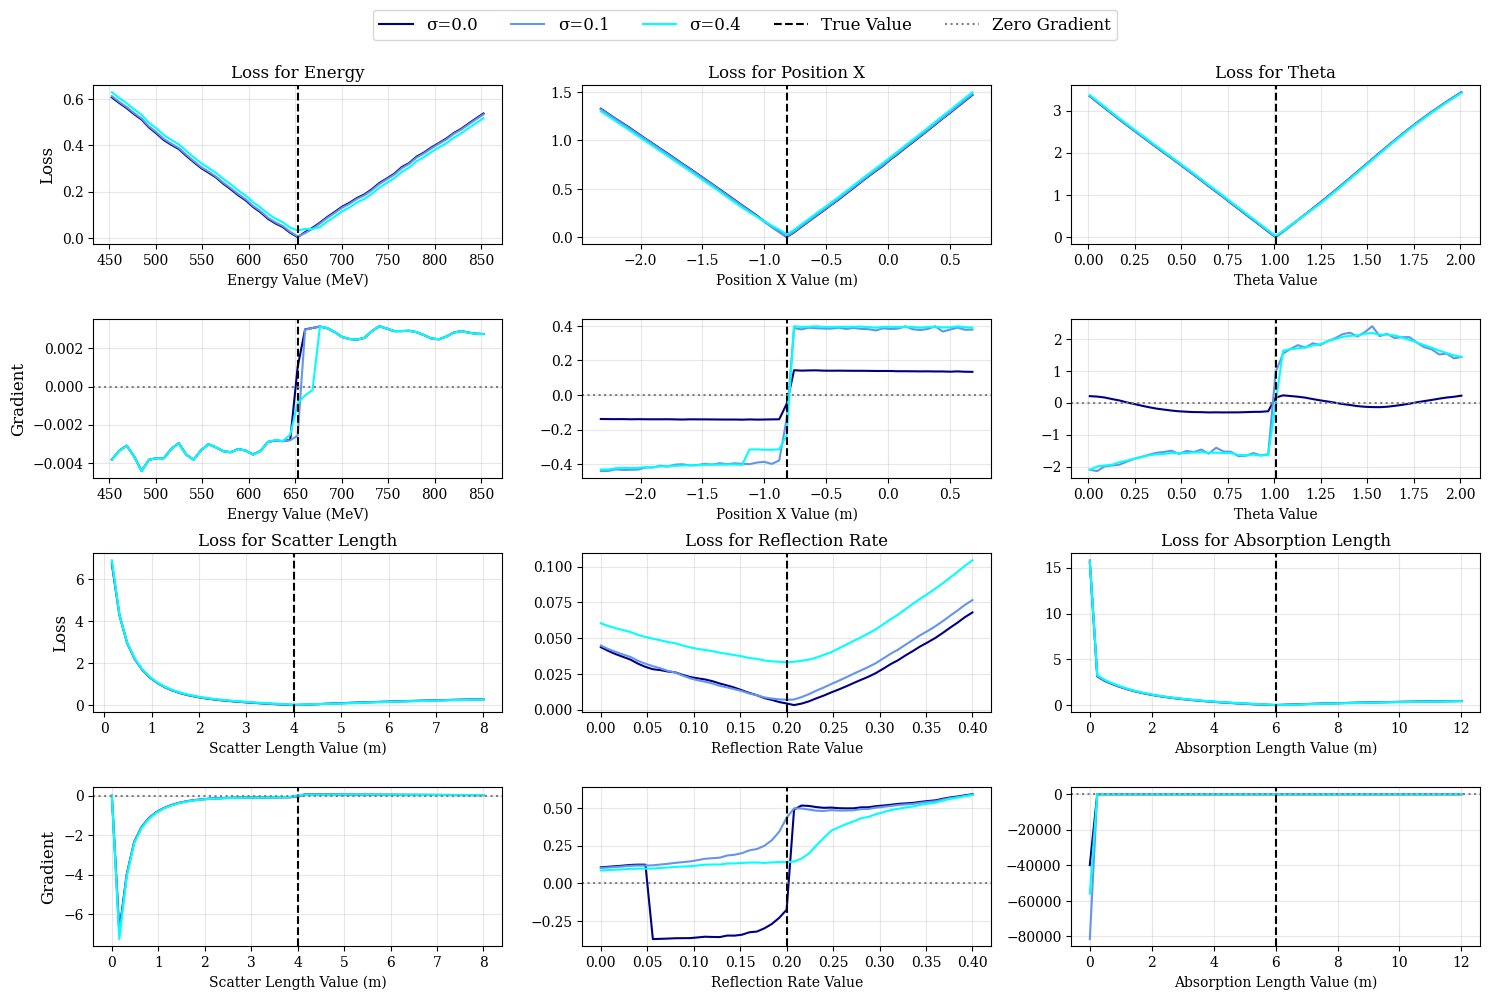

In [14]:
analysis_data = load_analysis_data(filename='output/grad_analysis_data.pkl')
fig, axs = plot_analysis_results(analysis_data)
plt.savefig('figures/extended_loss_and_grads_'+str(key_id)+'_'+str(Nphot)+'.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 2D Valley Analysis
# This is the case where we move closer to the wall and increase the opening angle. The gradient is the steepest in the direction of the valley.

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, value_and_grad
import matplotlib.pyplot as plt

# True parameters
true_params = (
    jnp.array(400.0),  # energy MeV
    jnp.array([0.0, 0.0, 0.0]),  # position
    jnp.array([1.0, 1.0]) # theta and phi in radians
)

key = jax.random.PRNGKey(1009)
# 
true_params = generate_random_params(key)

# Parameter changes
param_changes = (
    jnp.array(100.0),  # energy (only changing first component)
    jnp.array([1.0, 0.0, 0.0]),  # position (only changing first component)
    jnp.array([0.5, 0.0]) # theta and phi in radians
)

print(true_params)

In [ ]:
simulate_event = event_simulators[0.1]

In [ ]:
from tools.losses import compute_simplified_loss
from tqdm import tqdm

# Gradient scales
gradient_scales = jnp.array([0.001, 1, 1])
# gradient_scales = jnp.array([1.0, 1.0, 1.0, 1.0])

# Generate true data (without gradients)
key = jax.random.PRNGKey(1)
true_data = jax.lax.stop_gradient(simulate_true_data(true_params, detector_params, key))

true_data = (true_data[0], true_data[1])

def generate_param_ranges(true_params, param_changes, num_points=51):
    param_ranges = []
    for i, (true_param, change) in enumerate(zip(true_params, param_changes)):
        if i in [1, 2]:  # position and direction
            start = true_param[0] - change[0]
            end = true_param[0] + change[0]
        else:  # opening angle and intensity
            start = true_param - change
            end = true_param + change
        param_ranges.append(jnp.linspace(start, end, num_points))
    return param_ranges

@jit
def loss_and_grad(params):
    def loss_fn(params):
        simulated_data = simulate_event(params, detector_params, key)
        return compute_simplified_loss(detector_points, *true_data, *simulated_data, lambda_intensity=0.5, lambda_time=1.0)
    return value_and_grad(loss_fn)(params)

def generate_2d_plot_data(param_index1, param_index2, param_values1, param_values2):
    losses = jnp.zeros((len(param_values1), len(param_values2)))
    gradients = jnp.zeros((len(param_values1), len(param_values2), 2))

    total1 = len(param_values1)
    total2 = len(param_values2)
    
    for i, value1 in tqdm(enumerate(param_values1), total=total1, desc="Outer loop"):
        for j, value2 in enumerate(param_values2):
            new_params = list(true_params)
    
            if param_index1 in [1, 2]:
                new_params[param_index1] = new_params[param_index1].at[0].set(value1)
            else:
                new_params[param_index1] = value1
    
            if param_index2 in [1, 2]:
                new_params[param_index2] = new_params[param_index2].at[0].set(value2)
            else:
                new_params[param_index2] = value2
    
            new_params = tuple(new_params)
    
            loss, grad = loss_and_grad(new_params)
            gradient1 = grad[param_index1][0] if param_index1 in [1, 2] else grad[param_index1]
            gradient2 = grad[param_index2][0] if param_index2 in [1, 2] else grad[param_index2]
    
            # Rescale gradients
            gradient1 /= gradient_scales[param_index1]
            gradient2 /= gradient_scales[param_index2]
    
            losses = losses.at[i, j].set(loss)
            gradients = gradients.at[i, j].set(jnp.array([gradient1, gradient2]))

    return losses, gradients

In [ ]:
import numpy as np

def make_2D_grad_plot():
    #Create a single plot

    param_names = ['Energy', 'Position X', 'Theta']
    
    fig, ax = plt.subplots(figsize=(6, 3))
    
    # Plot 2D loss surface
    im = ax.imshow(losses.T, extent=[param_ranges[param_index1][0], param_ranges[param_index1][-1],
                                   param_ranges[param_index2][0], param_ranges[param_index2][-1]],
                  origin='lower', aspect='auto', cmap='coolwarm')
    fig.colorbar(im, ax=ax, label='Loss')
    
    # Create truly equally spaced coordinate arrays
    x_min, x_max = float(param_ranges[param_index1][0]), float(param_ranges[param_index1][-1])
    y_min, y_max = float(param_ranges[param_index2][0]), float(param_ranges[param_index2][-1])
    n_points_x = len(param_ranges[param_index1])
    n_points_y = len(param_ranges[param_index2])
    
    # Force equal spacing
    x = np.linspace(x_min, x_max, n_points_x)
    y = np.linspace(y_min, y_max, n_points_y)
    
    X, Y = np.meshgrid(x, y)
    
    # Convert gradients to numpy
    U = -1 * np.array(gradients[:, :, 0].T)
    V = -1 * np.array(gradients[:, :, 1].T)
    
    # Normalize gradients for better visualization
    norm = np.sqrt(U**2 + V**2)
    # Avoid division by zero
    norm = np.where(norm == 0, 1, norm)
    U_norm = U / norm
    V_norm = V / norm
    
    # Add streamplot on top of loss surface
    strm = ax.streamplot(X, Y, U_norm, V_norm, 
                        color='white',  # Using white for visibility
                        density=1.,      # Adjust density of streamlines
                        linewidth=1,    # Adjust line width
                        arrowsize=1)    # Adjust arrow size
    
    # Add marker for true parameter value
    true_value1 = true_params[param_index1] if param_index1 not in [1, 2] else true_params[param_index1][0]
    true_value2 = true_params[param_index2] if param_index2 not in [1, 2] else true_params[param_index2][0]
    ax.plot(true_value1, true_value2, color='springgreen', marker='*', linewidth=0, markersize=15, label='True Value')
    
    #ax.set_title(f'Loss Surface with Gradient Streamlines: {param_names[param_index1]} vs {param_names[param_index2]}')
    ax.set_xlabel(param_names[param_index1])
    ax.set_ylabel(param_names[param_index2])
    ax.legend()
    plt.gca().set_xlim(x_min,x_max)
    plt.tight_layout()
    figname = f'figures/2D_Grad_{param_names[param_index1]}_{param_names[param_index2]}.pdf'
    plt.savefig(figname)
    plt.show()


# Generate parameter ranges
num_points = 31
param_ranges = generate_param_ranges(true_params, param_changes, num_points)

idx_combinations = [(0,1), (0,2), (1,2)]

for idx_combo in idx_combinations:
    param_index1, param_index2 = idx_combo

    # Generate 2D plot data
    losses, gradients = generate_2d_plot_data(param_index1, param_index2, param_ranges[param_index1], param_ranges[param_index2])
    make_2D_grad_plot()

In [ ]:
# Create displays for true parameters and modified parameters

# Get a new random key
key_display = jax.random.PRNGKey(42)

# Create modified parameters by applying changes based on param_index1 and param_index2
modified_params = list(true_params)

# Modify first parameter (param_index1)
if param_index1 == 1:  # Position (vector parameter)
    modified_params[param_index1] = modified_params[param_index1].at[0].set(
        true_params[param_index1][0] + 0.9 * param_changes[param_index1][0]
    )
elif param_index1 == 2:  # Direction (vector parameter)
    # normalize the direction vector before setting it
    direction_vector = true_params[param_index1] + 0.9 * param_changes[param_index1][0]
    modified_params[param_index1] = direction_vector / jnp.linalg.norm(direction_vector)
else:  # Energy (scalar parameter)
    modified_params[param_index1] = true_params[param_index1] + 0.9 * param_changes[param_index1]

# Modify second parameter (param_index2)
if param_index2 == 1:  # Position (vector parameter)
    modified_params[param_index2] = modified_params[param_index2].at[0].set(
        true_params[param_index2][0] + 0.9 * param_changes[param_index2][0]
    )
elif param_index2 == 2:  # Direction (vector parameter)
    # normalize the direction vector before setting it
    direction_vector = true_params[param_index2] + 0.9 * param_changes[param_index2][0]
    modified_params[param_index2] = direction_vector / jnp.linalg.norm(direction_vector)
else:  # Energy (scalar parameter)
    modified_params[param_index2] = true_params[param_index2] + 0.9 * param_changes[param_index2]

modified_params = tuple(modified_params)

# Print both parameter sets
print("True Parameters:")
print_particle_params(true_params)
print("\nModified Parameters:")
print_particle_params(modified_params)

# Simulate events with both parameter sets
true_event_data = simulate_event(true_params, detector_params, key_display)
modified_event_data = simulate_event(modified_params, detector_params, key_display)

# Create detector display for visualization
detector_display = create_detector_display(default_json_filename ,sparse=False)

# Display the events
detector_display(*true_event_data, file_name=None, plot_time=False)
detector_display(*modified_event_data, file_name=None, plot_time=False)

# Also create time plots
detector_display(*true_event_data, file_name=None, plot_time=True)
detector_display(*modified_event_data, file_name=None, plot_time=True)

# Create comparison display to see differences
detector_comparison = create_detector_comparison_display(default_json_filename, sparse=False)
detector_comparison(true_event_data, modified_event_data, file_name=None, plot_time=False)
detector_comparison(true_event_data, modified_event_data, file_name=None, plot_time=True)